In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Data Cleaning

In [3]:
cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']

In [4]:
df = pd.read_csv('1803+784_dem.txt', sep='\s+', skiprows=4, names=cols, header=None, index_col=False)
df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
0,45754.258,-1.909625186745,-1.887001,1.2912,0.7417,-0.084,40.0
1,45759.251,-1.554359283060,-2.305602,1.2032,1.1362,0.028,19.0
2,45764.244,0.051039534973,1.460398,0.7069,0.6182,0.325,21.0
3,45769.259,-5.738531827789,0.891000,2.5316,1.1073,-0.363,25.0
4,45864.264,-2.972004238790,0.696600,0.6484,0.6307,0.547,27.0
...,...,...,...,...,...,...,...
2724,60181.271,-0.607553070938,-0.275702,0.2258,0.2346,0.037,65.0
2725,60188.269,0.015383760990,0.475898,0.1854,0.1910,0.278,107.0
2726,60195.271,0.066453528946,0.082897,0.1307,0.1282,0.102,201.0
2727,60202.270,-1.387176858925,-4.237200,0.1272,0.1330,0.139,98.0


In [5]:
# Drop problematic row
df = df.drop(df.index[2414])

In [6]:
df['MJD'] = pd.to_numeric(df['MJD'])

In [7]:
# Shift data values
df.iloc[2335, :] = df.iloc[2335, :].shift()
df.iloc[2335,0] = df.iloc[2335,1]

In [8]:
df.iloc[2335,1], df.iloc[2335,2] = df.iloc[2335,2].split('-')

In [9]:
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

In [10]:
df['Dec. (mas)'] = pd.to_numeric(df['Dec. (mas)'])

In [11]:
df.iloc[2335,2] *= -1

In [12]:
# Calculate RA*cos(dec) column
df['RAcosDEC'] = df['R.A. (mas)']*np.cos(df['Dec. (mas)'])

In [13]:
# Change MJD to BY 
# BY=2000-(51544.333981-MJD)/365.242198781
df['BY'] = 2000-(51544.333981-df['MJD'])/365.242198781

In [14]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,1.042109,1984.160968
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,0.005623,1984.174638
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-3.607440,1984.188369
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2.279611,1984.448484


In [15]:
# Take sample of 500 points
new_df = df.head(500)
new_df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,1.042109,1984.160968
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,0.005623,1984.174638
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-3.607440,1984.188369
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2.279611,1984.448484
...,...,...,...,...,...,...,...,...,...
495,47924.248,-0.517140,0.179197,0.2014,0.1885,-0.001,37.0,-0.508859,1990.088533
496,47924.263,1.401152,-0.518501,1.0874,0.9552,-0.166,6.0,1.216989,1990.088574
497,47929.249,0.834742,-0.383900,0.1631,0.1506,-0.012,46.0,0.773982,1990.102225
498,47930.330,-1.496723,-0.170402,0.2934,0.3239,0.098,3.0,-1.475045,1990.105185


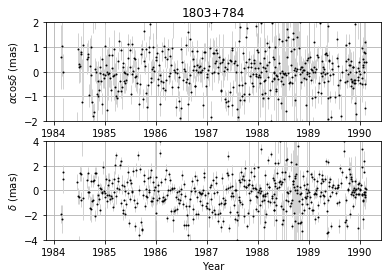

In [16]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(new_df['BY'], new_df['RAcosDEC'],yerr=new_df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(new_df['BY'], new_df['Dec. (mas)'], yerr=new_df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

# Allan variance with WMA

In [17]:
# Start and end date
start_date = new_df['MJD'].values.min()
end_date = new_df['MJD'].values.max()

print(start_date,end_date)

45754.258 47931.082


In [18]:
start_date = math.trunc(start_date)
end_date = math.trunc(end_date)

print(start_date,end_date)

45754 47931


In [19]:
# Length of observation
N = int(round((end_date - start_date)))
N

2177

In [20]:
# Make array of start to end date 
real_dates = np.arange(start_date,1+end_date,1)
real_dates

array([45754, 45755, 45756, ..., 47929, 47930, 47931])

In [21]:
dates_df = pd.DataFrame(real_dates, columns=['MJDReal'])
dates_df

,MJDReal
0,45754
1,45755
2,45756
3,45757
4,45758
...,...
2173,47927
2174,47928
2175,47929
2176,47930


In [22]:
# Truncate the MJD column in new_df 
new_df['MJDtrunc'] = new_df['MJD'].apply(math.trunc)
new_df

/home/anto/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY,MJDtrunc
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297,45754
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,1.042109,1984.160968,45759
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,0.005623,1984.174638,45764
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-3.607440,1984.188369,45769
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2.279611,1984.448484,45864
...,...,...,...,...,...,...,...,...,...,...
495,47924.248,-0.517140,0.179197,0.2014,0.1885,-0.001,37.0,-0.508859,1990.088533,47924
496,47924.263,1.401152,-0.518501,1.0874,0.9552,-0.166,6.0,1.216989,1990.088574,47924
497,47929.249,0.834742,-0.383900,0.1631,0.1506,-0.012,46.0,0.773982,1990.102225,47929
498,47930.330,-1.496723,-0.170402,0.2934,0.3239,0.098,3.0,-1.475045,1990.105185,47930


In [23]:
merge_df = new_df.merge(dates_df, how='right',left_on='MJDtrunc',right_on='MJDReal')
merge_df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY,MJDtrunc,MJDReal
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297,45754.0,45754
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,1.042109,1984.160968,45759.0,45759
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,0.005623,1984.174638,45764.0,45764
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-3.607440,1984.188369,45769.0,45769
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2.279611,1984.448484,45864.0,45864
...,...,...,...,...,...,...,...,...,...,...,...
2186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47923
2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47925
2188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47926
2189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47927


In [24]:
merge_df = merge_df.sort_values(by=['MJDReal'])
merge_df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY,MJDtrunc,MJDReal
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297,45754.0,45754
500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45755
501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45756
502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45757
503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45758
...,...,...,...,...,...,...,...,...,...,...,...
2189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47927
2190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47928
497,47929.249,0.834742,-0.383900,0.1631,0.1506,-0.012,46.0,0.773982,1990.102225,47929.0,47929
498,47930.330,-1.496723,-0.170402,0.2934,0.3239,0.098,3.0,-1.475045,1990.105185,47930.0,47930


In [25]:
merge_df = merge_df.fillna(0)
merge_df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY,MJDtrunc,MJDReal
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297,45754.0,45754
500,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,45755
501,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,45756
502,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,45757
503,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,45758
...,...,...,...,...,...,...,...,...,...,...,...
2189,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47927
2190,0.000,0.000000,0.000000,0.0000,0.0000,0.000,0.0,0.000000,0.000000,0.0,47928
497,47929.249,0.834742,-0.383900,0.1631,0.1506,-0.012,46.0,0.773982,1990.102225,47929.0,47929
498,47930.330,-1.496723,-0.170402,0.2934,0.3239,0.098,3.0,-1.475045,1990.105185,47930.0,47930


In [26]:
merge_df.to_csv('merge_df.csv', index=False)

In [27]:
# m array where 3 < m < N/3 
m = np.arange(3,1+round(N//3),1)
# Take tau0 as 1/rate
rate = 1
tau0 = 1/rate
# steps
step = 1

# Empty variance array
allanvar = []
# Empty tau values array 
tau = []

# Create weights 
weights_std = 1/(merge_df['Err. R.A. (mas)'].values**2)


/home/anto/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app


In [28]:
f = open("loop.txt", "a")

In [31]:
# Iterate over values of m
for k in range(len(m)): 
    print('==========')
    print('Current value of m: ' + str(m[k]))
    # Sliding windows 
    left = 0 
    right = m[k]
    ybar = []
    D = 0
    data_sum = 0
        
    # Check for missing windows 
    while right <= N:
        data_values = merge_df['R.A. (mas)'].values[left:right]
        data_sum = np.sum(data_values)
#         f.write('Current values' + str(data_values))
#         print('Current data sum' + str(data_sum))
    
        if data_sum == 0:
            D +=1
        else:
            # windows berdasarkan waktu bukan data
            # misal hari ke 1,2,3 bukan indeks data (1,3,6..)
            ybar.append(np.average(merge_df['R.A. (mas)'].values[left:right], weights=weights_std[left:right]))
        left += step 
        right += step    
            
    print('Total amount of missing windows D: ' + str(D))

    # M is the number of times we can move the averaging window from the beginning to the end
    M = len(ybar)
    print('Current value of M: ' + str(M))
    print('M-2m+1-D value: ' + str(M-2*m[k]+1-D))

Current value of m: 3
Total amount of missing windows D: 874
Current value of M: 1301
M-2m+1-D value: 422
Current value of m: 4
Total amount of missing windows D: 505
Current value of M: 1669
M-2m+1-D value: 1157
Current value of m: 5
Total amount of missing windows D: 177
Current value of M: 1996
M-2m+1-D value: 1810
Current value of m: 6
Total amount of missing windows D: 152
Current value of M: 2020
M-2m+1-D value: 1857
Current value of m: 7
Total amount of missing windows D: 134
Current value of M: 2037
M-2m+1-D value: 1890
Current value of m: 8
Total amount of missing windows D: 124
Current value of M: 2046
M-2m+1-D value: 1907
Current value of m: 9
Total amount of missing windows D: 116
Current value of M: 2053
M-2m+1-D value: 1920
Current value of m: 10
Total amount of missing windows D: 110
Current value of M: 2058
M-2m+1-D value: 1929
Current value of m: 11
Total amount of missing windows D: 107
Current value of M: 2060
M-2m+1-D value: 1932
Current value of m: 12
Total amount 

In [78]:
# Calculate allan std dev
allanstd = np.sqrt(allanvar)

In [79]:
tau_year = [x/365.242198781 for x in tau]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

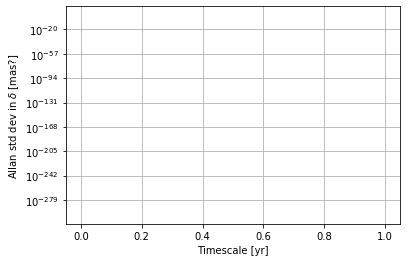

In [80]:
plt.plot(tau_year, allanstd)
plt.yscale('log')
# plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')